# Подготовка

In [66]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import sklearn

Константа для воспроизводимости результата.

In [5]:
RANDOM_STATE = 2026

Настройки для оформления визуализаций

In [ ]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

RANDOM_STATE = 2026

Загрузка данных

In [6]:
df = pd.read_csv("marketing_sales_dataset.csv")

In [7]:
df.head()

,id,date,region,sales_channel,product_category,customer_segment,season,marketing_budget_usd,ad_spend_online_usd,ad_spend_offline_usd,...,customer_age,customer_satisfaction_score,competitor_price_index,website_traffic,conversion_rate,email_open_rate,social_media_followers,days_since_last_purchase,num_previous_purchases,sales_revenue_usd
0,1,2020-11-12,Riyadh,Retail Store,Cosmetics,Regular,Q4,1664.51,952.30,326.97,...,42,4.5,0.76,1952,0.1193,0.0410,2034,25.0,6,3772.90
1,2,2022-07-05,Dubai,Online,Cosmetics,New,Q3,2452.29,1014.25,414.76,...,24,3.7,1.07,3185,0.0404,0.3166,2058,187.0,7,2091.36
2,3,2020-11-11,Riyadh,Online,Electronics,Regular,Q4,1026.13,328.30,242.72,...,32,2.0,1.18,1304,0.1459,0.3033,417,139.0,3,6201.11
3,4,2022-10-01,Cairo,Online,Electronics,Regular,Q4,1102.86,628.30,204.58,...,62,2.6,0.86,1609,0.0460,0.1138,20618,308.0,6,4911.38
4,5,2023-12-12,Cairo,Retail Store,Food & Beverage,Corporate,Q4,2517.55,777.24,817.88,...,23,3.0,1.01,366639,0.1670,0.1826,57116,97.0,6,7705.73


In [8]:
print(f"Количество наблюдений: {df.shape[0]}")
print(f"Количество признаков: {df.shape[1]}")

Количество наблюдений: 60000
Количество признаков: 23


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           60000 non-null  int64  
 1   date                         60000 non-null  str    
 2   region                       60000 non-null  str    
 3   sales_channel                60000 non-null  str    
 4   product_category             60000 non-null  str    
 5   customer_segment             60000 non-null  str    
 6   season                       60000 non-null  str    
 7   marketing_budget_usd         60000 non-null  float64
 8   ad_spend_online_usd          60000 non-null  float64
 9   ad_spend_offline_usd         60000 non-null  float64
 10  num_promotions               60000 non-null  int64  
 11  discount_percentage          58192 non-null  float64
 12  num_sales_representatives    60000 non-null  int64  
 13  customer_age               

Проверка качества данных

In [17]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame(name="Количество пропусков")
)

missing

,Количество пропусков
customer_satisfaction_score,1844
days_since_last_purchase,1836
discount_percentage,1808
email_open_rate,1790
id,0
date,0
region,0
season,0
customer_segment,0
product_category,0


Проверяем на дубликаты

In [16]:
duplicates = df.duplicated().sum()

print(f"Количество дубликатов: {duplicates}")

Количество дубликатов: 0


Заменяем пропуски на медиану

In [19]:
cols = [
    "customer_satisfaction_score",
    "days_since_last_purchase",
    "discount_percentage",
    "email_open_rate"
]

for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [20]:
df.isna().sum()

id                             0
date                           0
region                         0
sales_channel                  0
product_category               0
customer_segment               0
season                         0
marketing_budget_usd           0
ad_spend_online_usd            0
ad_spend_offline_usd           0
num_promotions                 0
discount_percentage            0
num_sales_representatives      0
customer_age                   0
customer_satisfaction_score    0
competitor_price_index         0
website_traffic                0
conversion_rate                0
email_open_rate                0
social_media_followers         0
days_since_last_purchase       0
num_previous_purchases         0
sales_revenue_usd              0
dtype: int64

# EDA

Рассмотрим распределение выручки

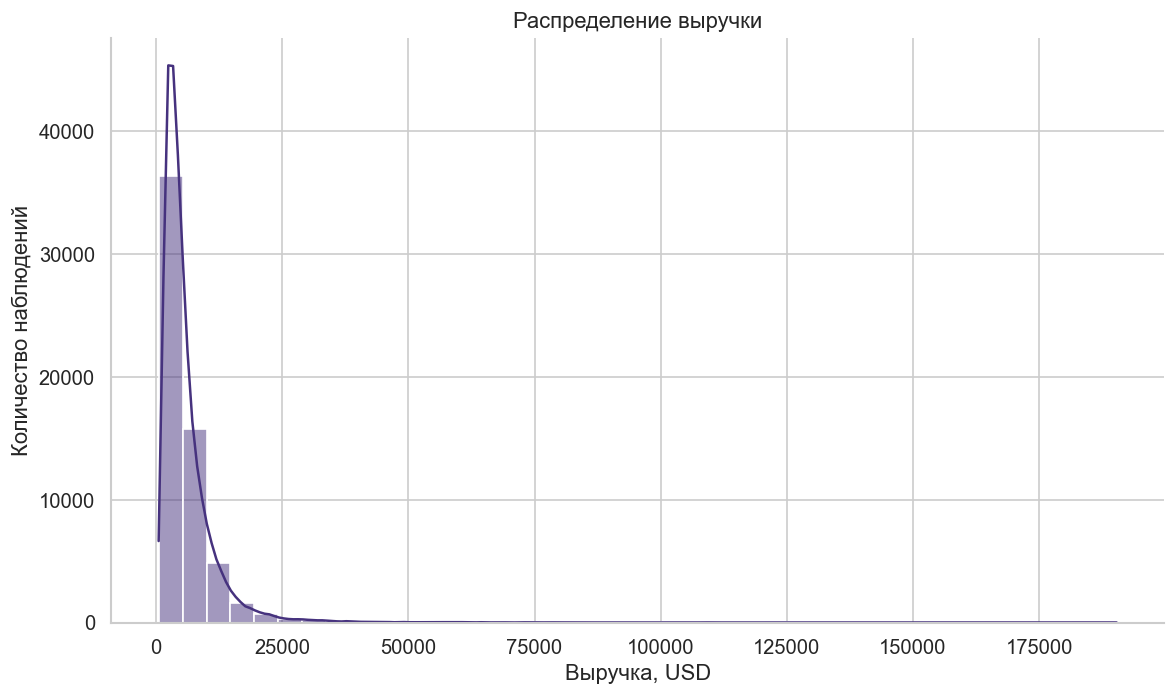

In [37]:
sns.histplot(
    data=df,
    x="sales_revenue_usd",
    bins=40,
    kde=True
)

plt.title("Распределение выручки")
plt.xlabel("Выручка, USD")
plt.ylabel("Количество наблюдений")

sns.despine()
plt.tight_layout()
plt.show()

Рассмотрим выбросы

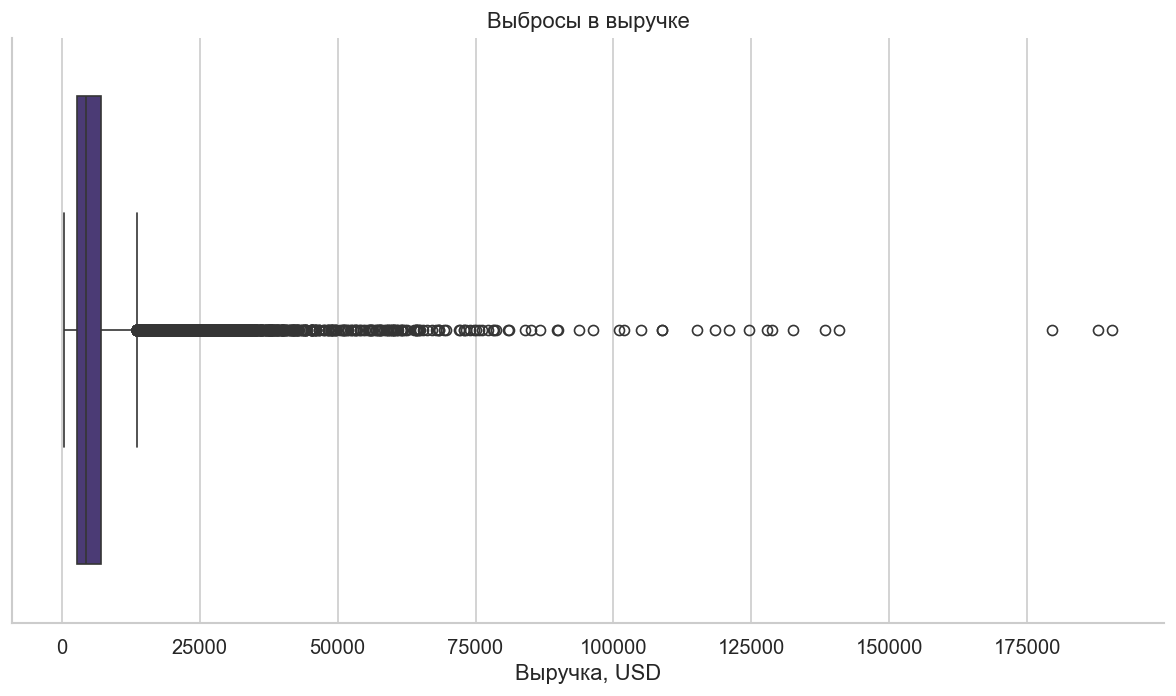

In [38]:
sns.boxplot(
    data=df,
    x="sales_revenue_usd"
)

plt.title("Выбросы в выручке")
plt.xlabel("Выручка, USD")

sns.despine()
plt.tight_layout()
plt.show()

Основной вклад в выручку дают сделки в диапазоне ~2700 - ~7100

Связь выручки и маркетингового бюджета

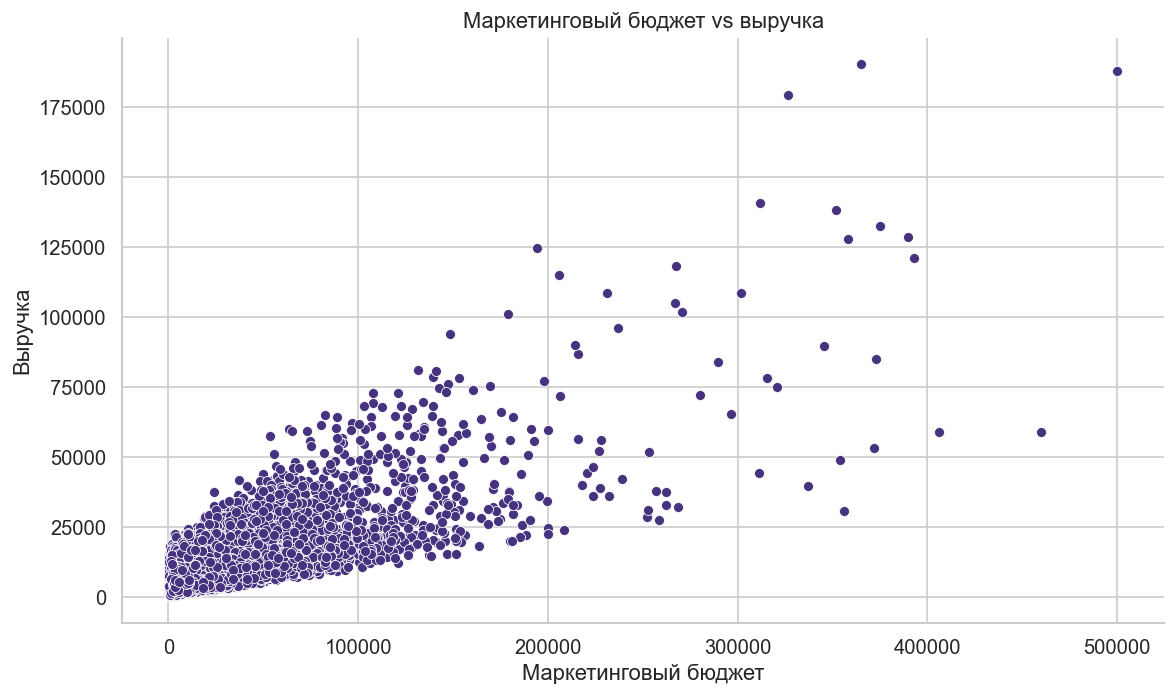

In [39]:
sns.scatterplot(
    data=df,
    x="marketing_budget_usd",
    y="sales_revenue_usd"
)

plt.title("Маркетинговый бюджет vs выручка")
plt.xlabel("Маркетинговый бюджет")
plt.ylabel("Выручка")

sns.despine()
plt.tight_layout()
plt.show()

Увеличение маркетингового бюджета не гарантирует роста выручки

Связь выручки и конверсии

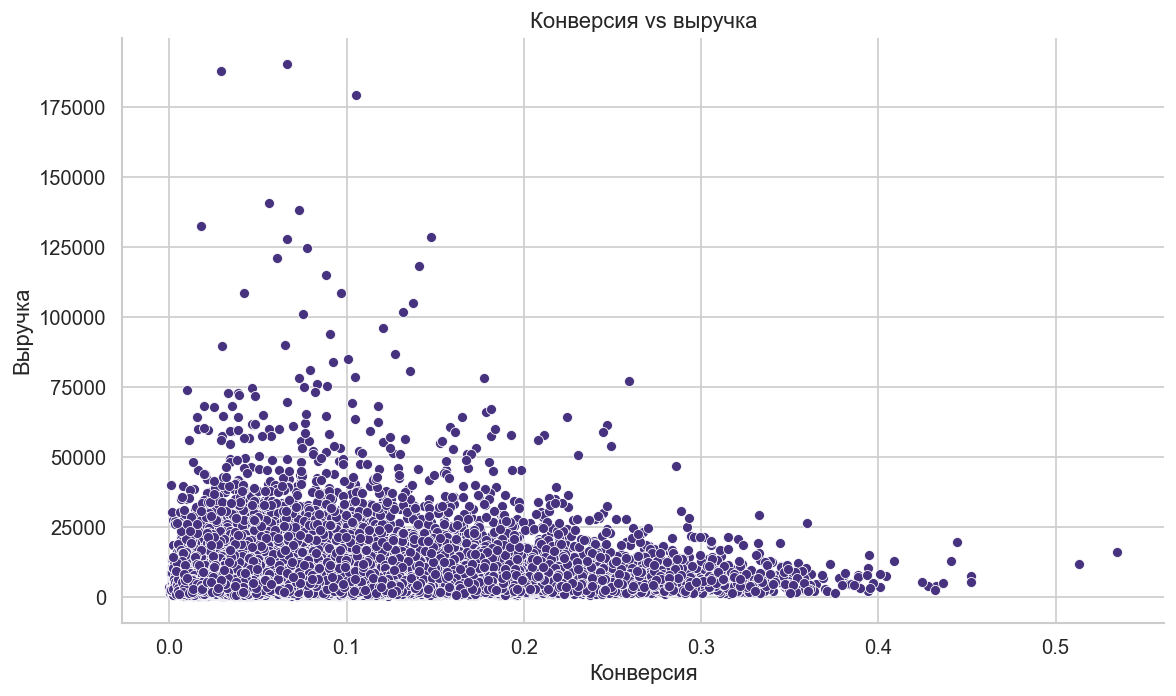

In [40]:
sns.scatterplot(
    data=df,
    x="conversion_rate",
    y="sales_revenue_usd"
)

plt.title("Конверсия vs выручка")
plt.xlabel("Конверсия")
plt.ylabel("Выручка")

sns.despine()
plt.tight_layout()
plt.show()

Связи между конверсией и выручкой нет

Связь выручки и веб-трафика

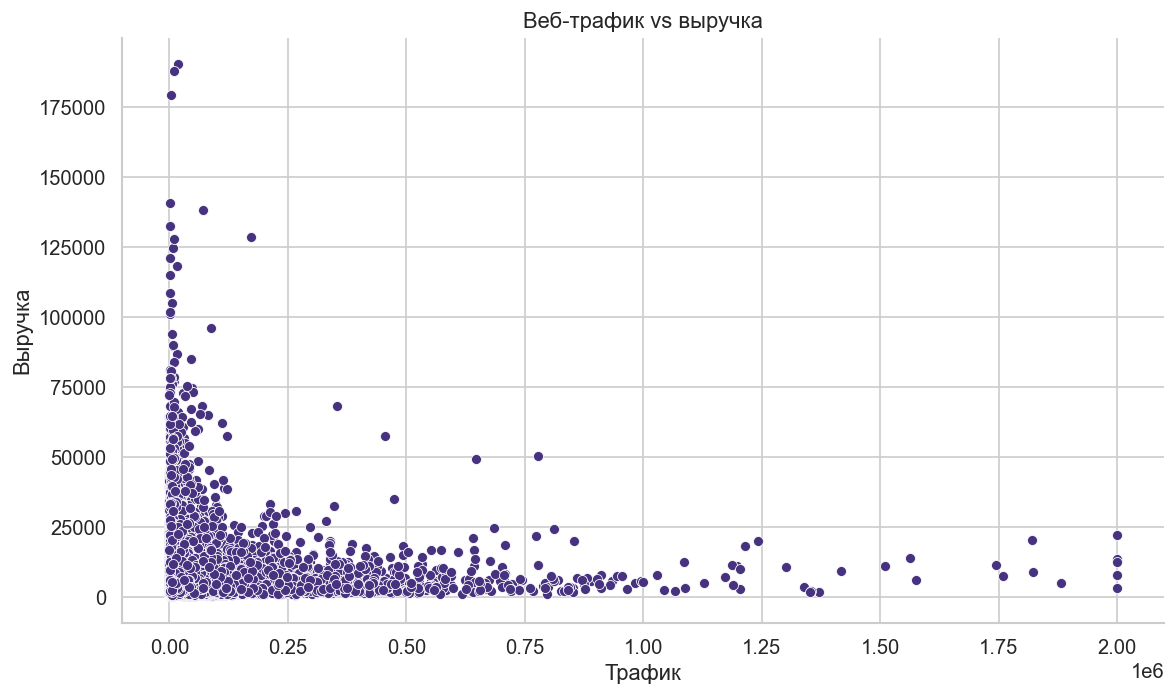

In [41]:
sns.scatterplot(
    data=df,
    x="website_traffic",
    y="sales_revenue_usd"
)

plt.title("Веб-трафик vs выручка")
plt.xlabel("Трафик")
plt.ylabel("Выручка")

sns.despine()
plt.tight_layout()
plt.show()

Высокий трафик не гарантирует высокую выручку

Связь выручки и скидок

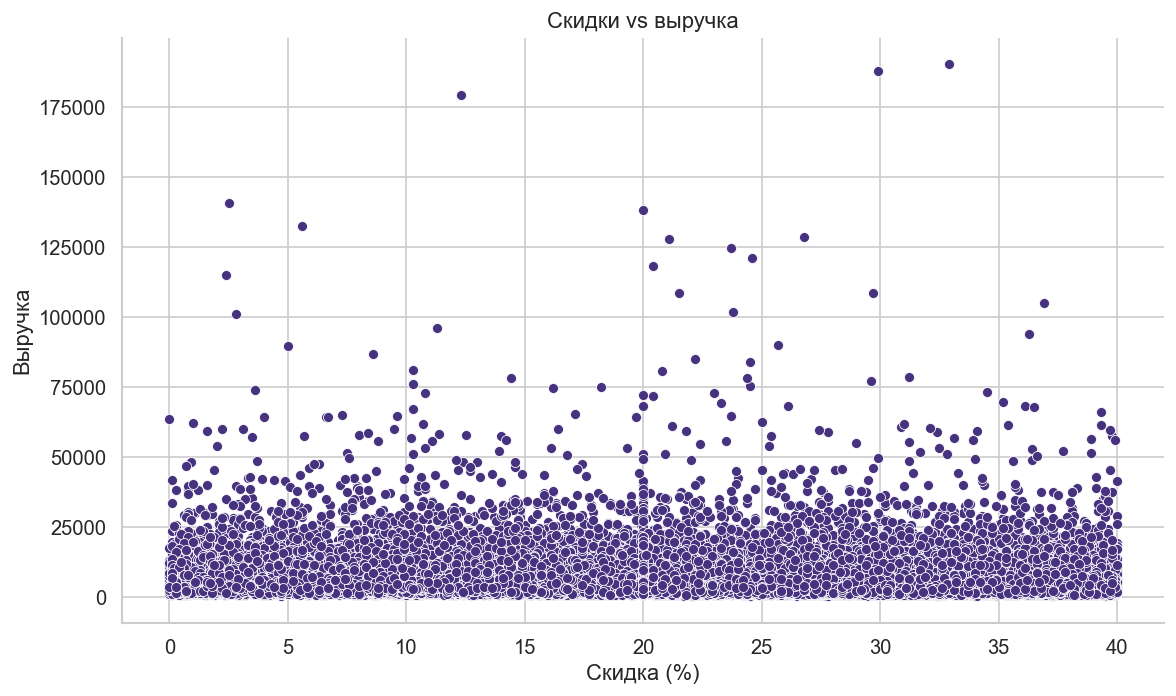

In [42]:
sns.scatterplot(
    data=df,
    x="discount_percentage",
    y="sales_revenue_usd"
)

plt.title("Скидки vs выручка")
plt.xlabel("Скидка (%)")
plt.ylabel("Выручка")

sns.despine()
plt.tight_layout()
plt.show()

Связи между выручкой и скидкой нет

# EDA: категории

Связь выручки и каналов продаж

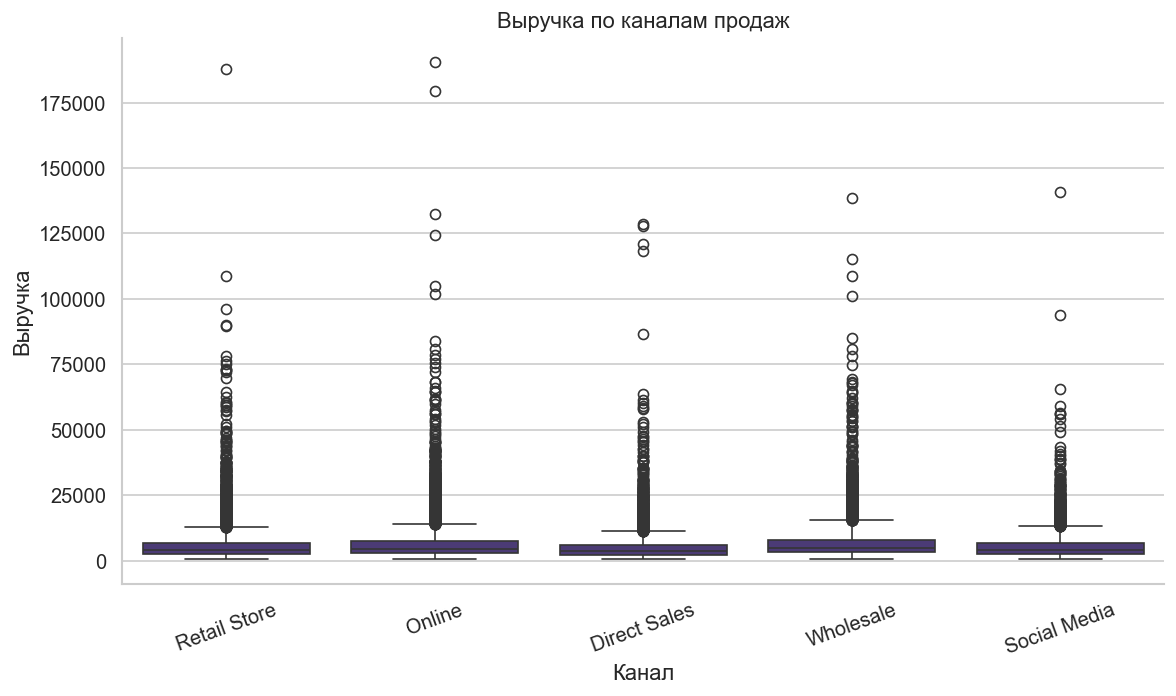

In [43]:
sns.boxplot(
    data=df,
    x="sales_channel",
    y="sales_revenue_usd"
)

plt.title("Выручка по каналам продаж")
plt.xlabel("Канал")
plt.ylabel("Выручка")

plt.xticks(rotation=20)

sns.despine()
plt.tight_layout()
plt.show()

Канал продаж не определяет размер выручки. Крупные сделки (100,000+) случаются в любом канале.

Связь выручки и типа клиентов

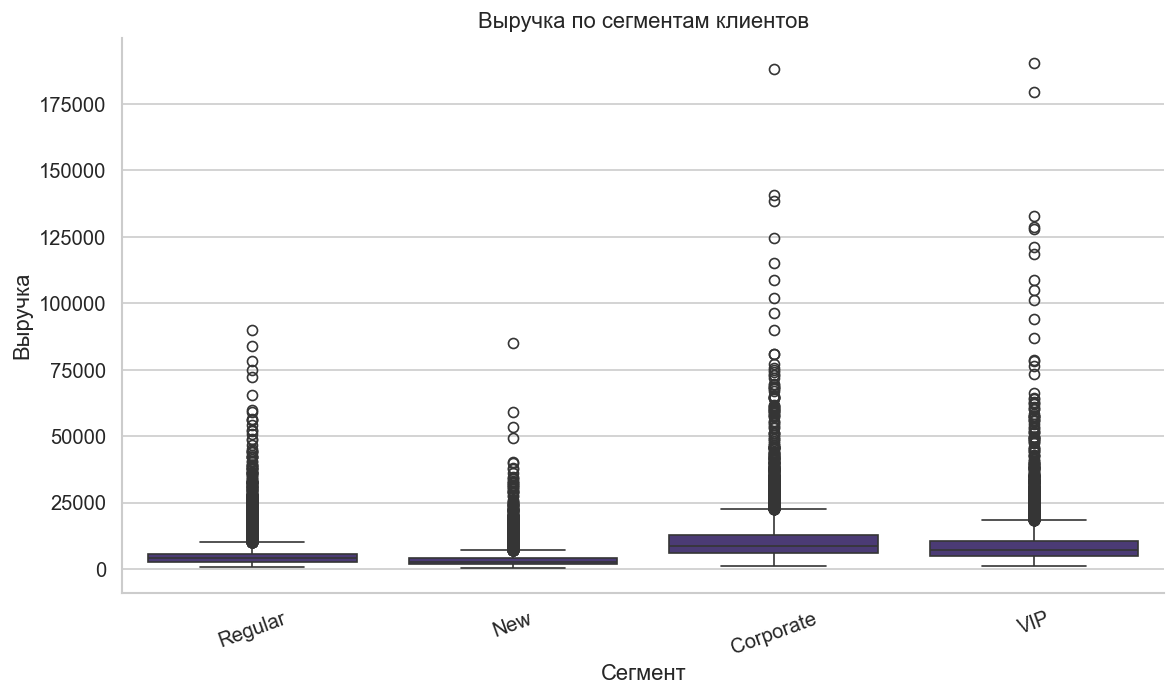

In [44]:
sns.boxplot(
    data=df,
    x="customer_segment",
    y="sales_revenue_usd"
)

plt.title("Выручка по сегментам клиентов")
plt.xlabel("Сегмент")
plt.ylabel("Выручка")

plt.xticks(rotation=20)

sns.despine()
plt.tight_layout()
plt.show()

Сегмент клиента влияет на выручку. VIP и Corporate приносят более высокую выручку, чем Regular и New.

Связь выручки и категории продукта

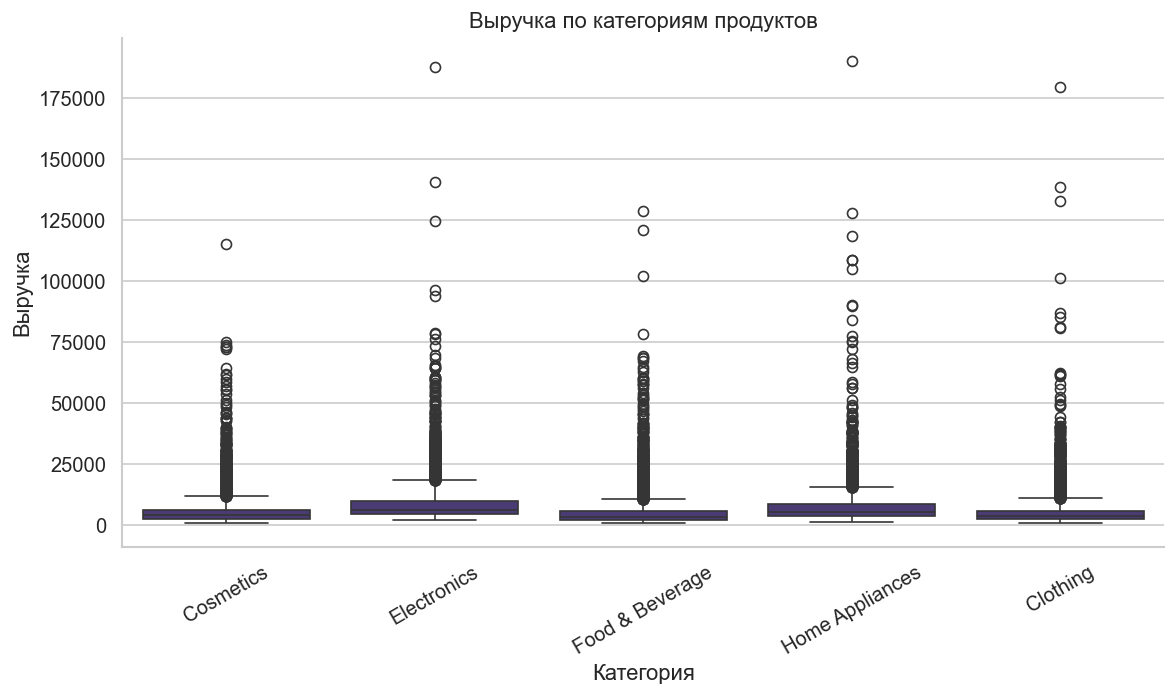

In [45]:
sns.boxplot(
    data=df,
    x="product_category",
    y="sales_revenue_usd"
)

plt.title("Выручка по категориям продуктов")
plt.xlabel("Категория")
plt.ylabel("Выручка")

plt.xticks(rotation=30)

sns.despine()
plt.tight_layout()
plt.show()

Категория продуктов  влияет на выручку. Electronics и Home Appliances приносят больше.

# EDA: корреляции

Какие числовые признаки связаны между собой

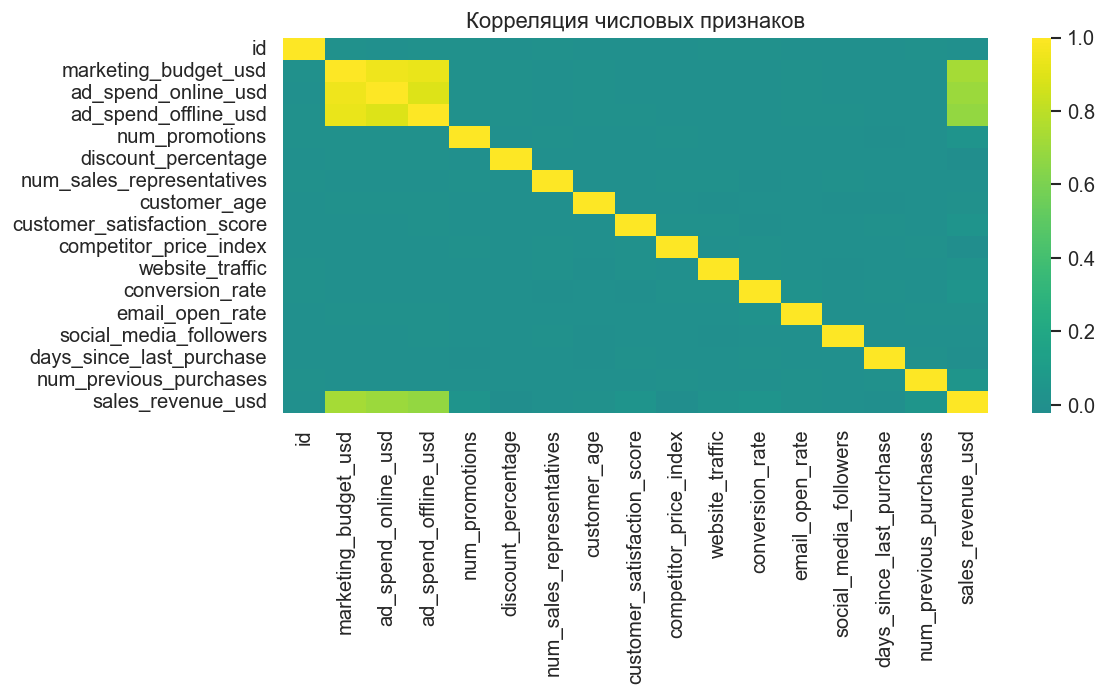

In [46]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr, cmap="viridis", center=0)

plt.title("Корреляция числовых признаков")

plt.tight_layout()
plt.show()

Линейной зависимости между отдельными числовыми признаками и выручкой нет. Для предсказания выручки нужны нелинейные модели или комбинации признаков.

# Гипотезы и их проверки

Гипотеза 1: Высокие затраты на рекламу приводят к увеличению выручки.

In [51]:
df['marketing_budget_usd'].corr(df['sales_revenue_usd'])

np.float64(0.7273012588708051)

In [52]:
df['is_big'] = df['sales_revenue_usd'] > df['sales_revenue_usd'].quantile(0.95)
df.groupby('is_big')['marketing_budget_usd'].mean().round(2)

is_big
False     7932.68
True     49917.26
Name: marketing_budget_usd, dtype: float64

Корреляция между рекламным бюджетом и выручкой возникла, потому что на крупные сделки выделяется больше бюджета. Гипотеза отвергается.

Гипотеза 2: Увеличение размера скидки приводит к снижению выручки.

In [59]:
f_stat, p_value = stats.f_oneway(
    df[df['discount_group'] == '0-10%']['sales_revenue_usd'],
    df[df['discount_group'] == '10-20%']['sales_revenue_usd'],
    df[df['discount_group'] == '20-30%']['sales_revenue_usd'],
    df[df['discount_group'] == '30%+']['sales_revenue_usd']
)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.10f}")

F-statistic: 8.4861
P-value: 0.0000124139


Гипотеза подтвердилась. Увеличение скидки приводит к статистически значимому снижению выручки

Гипотеза 3: Чем больше у клиента предыдущих покупок (num_previous_purchases), тем выше его средний чек

In [63]:
correlation = df['num_previous_purchases'].corr(df['avg_check'])
print(f"Корреляция: {correlation:.4f}")

Корреляция: -0.3547


Гипотеза не подтвердилась. Чем больше предыдущих покупок, тем меньше средний чек.

Гипотеза: Q4 приносит максимальную выручку во всех регионах

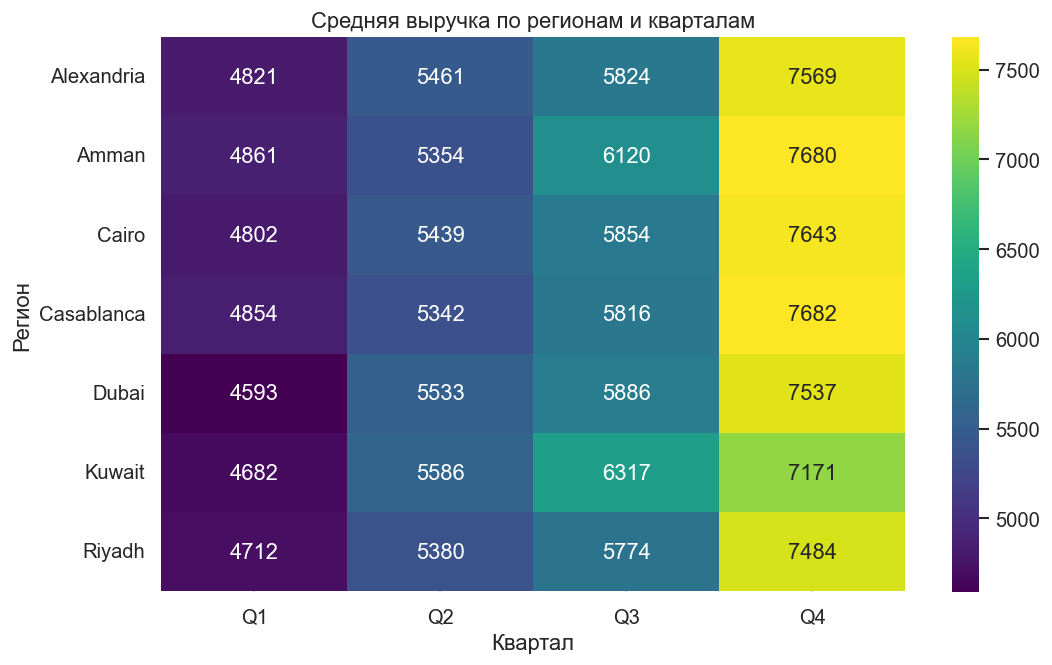

In [65]:
pivot_table = df.pivot_table(values='sales_revenue_usd', index='region', columns='season', aggfunc='mean')

sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='viridis')
plt.title('Средняя выручка по регионам и кварталам')
plt.xlabel('Квартал')
plt.ylabel('Регион')
plt.show()

Гипотеза подтвердилась.

# Выводы:
* Увеличивать рекламный бюджет бессмысленно
* Скидки выше 20% не работают
* Регион не имеет значения
* Q4 — окно возможностей

# Моделирование для предсказания выручки

In [71]:
X = df.drop(['sales_revenue_usd', 'id', 'date'], axis=1)
y = df['sales_revenue_usd']

categorical_features = ['region', 'sales_channel', 'product_category', 'customer_segment', 'season']
numerical_features = [col for col in X.columns if col not in categorical_features and X[col].dtype in ['int64', 'float64']]

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

preprocessor = sklearn.compose.ColumnTransformer([
    ('cat', sklearn.preprocessing.OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('num', sklearn.preprocessing.StandardScaler(), numerical_features)
])

model = sklearn.ensemble.RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

pipeline = sklearn.pipeline.Pipeline([('preprocessor', preprocessor), ('model', model)])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print(f"MAE: {sklearn.metrics.mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2: {sklearn.metrics.r2_score(y_test, y_pred):.4f}")

MAE: 53.58
R2: 0.9795


Модель Random Forest предсказывает выручку с точностью 54 USD и объясняет 98% дисперсии. Существует сильная нелинейная зависимость выручки от доступных признаков.

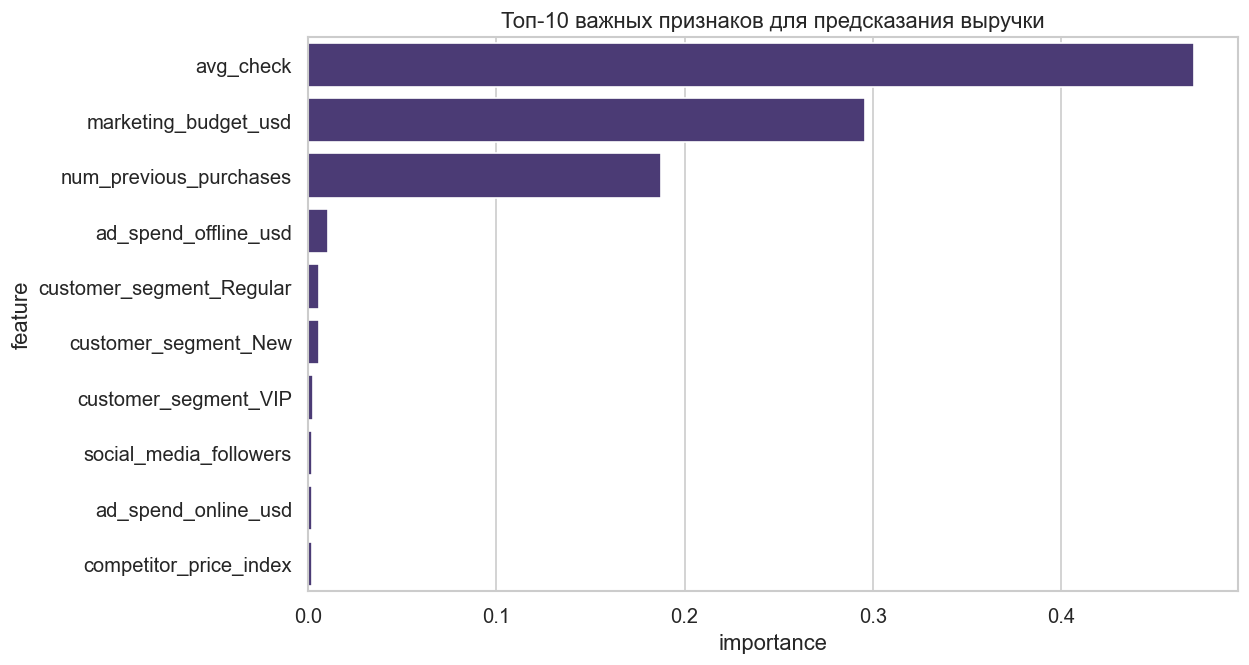

In [72]:
feature_names = (pipeline.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .get_feature_names_out(categorical_features).tolist())
feature_names += numerical_features

importances = pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Топ-10 важных признаков для предсказания выручки')
plt.show()

Слишком сильное влияние созданного нами признака.

Переобучаем модель.

In [73]:
X = df.drop(['sales_revenue_usd', 'id', 'date', 'avg_check'], axis=1)
y = df['sales_revenue_usd']

categorical_features = ['region', 'sales_channel', 'product_category', 'customer_segment', 'season']
numerical_features = [col for col in X.columns if col not in categorical_features and X[col].dtype in ['int64', 'float64']]

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

preprocessor = sklearn.compose.ColumnTransformer([
    ('cat', sklearn.preprocessing.OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('num', sklearn.preprocessing.StandardScaler(), numerical_features)
])

model = sklearn.ensemble.RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

pipeline = sklearn.pipeline.Pipeline([('preprocessor', preprocessor), ('model', model)])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print(f"MAE: {sklearn.metrics.mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2: {sklearn.metrics.r2_score(y_test, y_pred):.4f}")

MAE: 719.20
R2: 0.9369


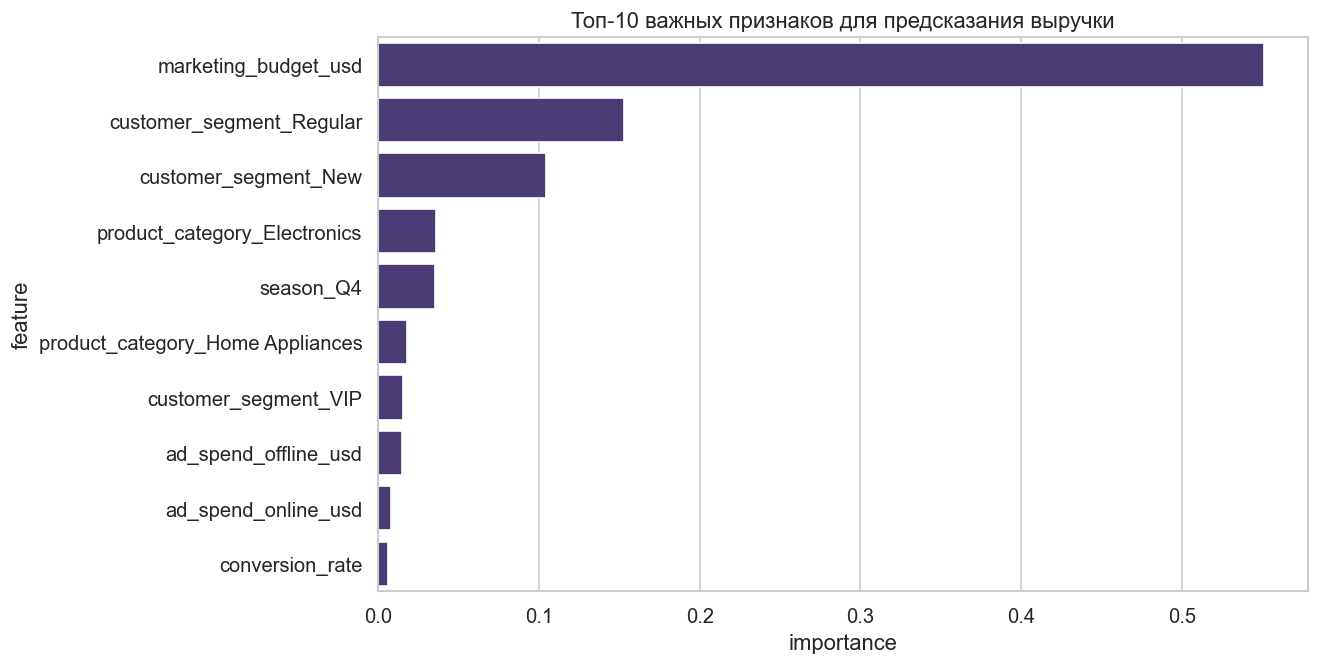

In [74]:
feature_names = (pipeline.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .get_feature_names_out(categorical_features).tolist())
feature_names += numerical_features

importances = pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Топ-10 важных признаков для предсказания выручки')
plt.show()

Вывод: модель все еще хорошо предсказывает выручку. EDA не показал линейных связей, но Random Forest нашёл нелинейные. Бюджет, сегмент клиента, категория товара, сезон и конверсия влияют на выручку.

Посмотрим ошибки модели.

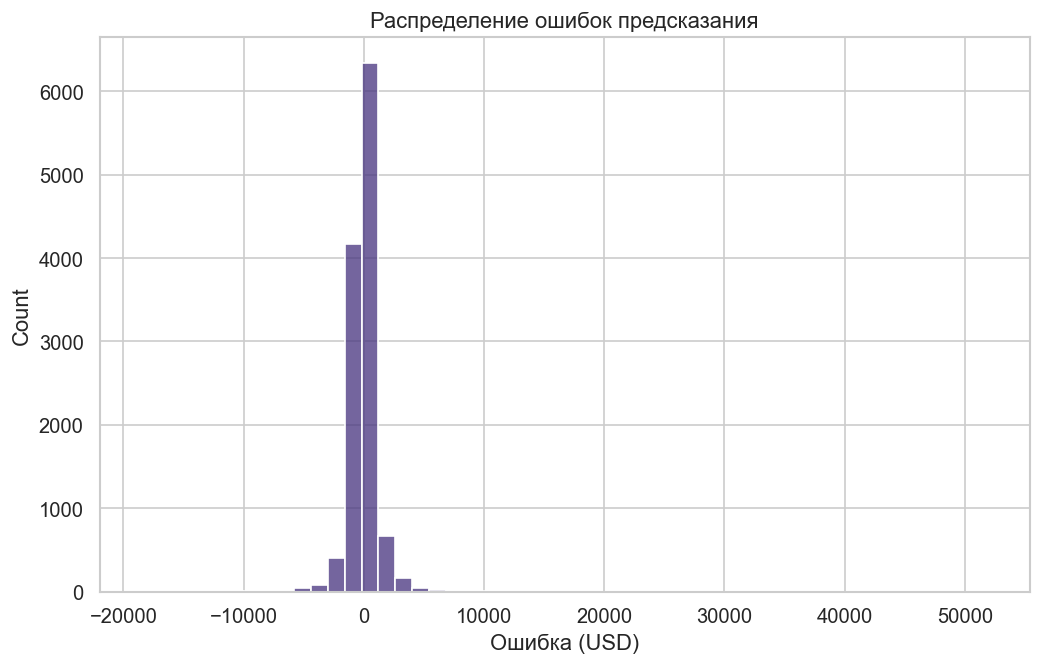

In [ ]:
errors = y_test - y_pred
sns.histplot(errors, bins=50)
plt.title('Распределение ошибок предсказания')
plt.xlabel('Ошибка (USD)')
plt.show()

Сравним предсказания и реальные данные

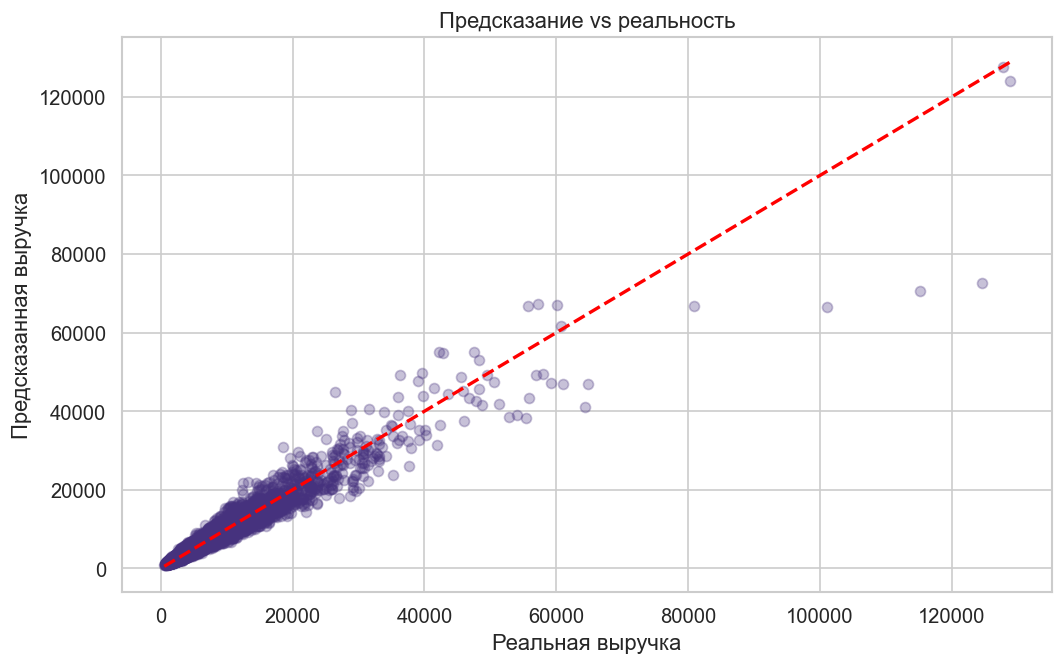

In [78]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная выручка')
plt.ylabel('Предсказанная выручка')
plt.title('Предсказание vs реальность')
plt.show()

Посмотрим на предсказания моделью крупных сделок

In [79]:
df_test = X_test.copy()
df_test['actual'] = y_test
df_test['predicted'] = y_pred
df_test['is_big_actual'] = df_test['actual'] > 50000
df_test['is_big_predicted'] = df_test['predicted'] > 50000

from sklearn.metrics import classification_report
print(classification_report(df_test['is_big_actual'], df_test['is_big_predicted']))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00     11978
        True       0.71      0.45      0.56        22

    accuracy                           1.00     12000
   macro avg       0.86      0.73      0.78     12000
weighted avg       1.00      1.00      1.00     12000



Модель почти не предсказывает крупные сделки. Для их прогнозирования нужна отдельная модель.